In [1]:
# Skipped in CI: Colab/bootstrap dependency install cell.


# PyCBC 連携：gwexpy 前処理から重力波探索まで

[PyCBC](https://pycbc.org/) は連星合体（CBC）のマッチトフィルター探索や
パラメータ推定を行う重力波データ解析ツールキットです。
gwexpy は自身のデータ型と PyCBC の `TimeSeries` / `FrequencySeries` 間の
**双方向コンバータ**を提供します。

これにより、以下のような自然なワークフローが実現します：
- **gwexpy**: データ読み込み、前処理、ノイズ特性評価
- **PyCBC**: マッチトフィルター探索やパラメータ推定
- **gwexpy**: 探索結果の後処理と可視化

**このチュートリアルで学ぶこと：**
1. gwexpy `TimeSeries` を PyCBC に変換して戻す
2. gwexpy `FrequencySeries`（ASD）を PyCBC PSD に変換する
3. 完全な前処理パイプライン：コンディショニング → マッチトフィルター
4. gwexpy で SNR 時系列を可視化する

> **注意**: PyCBC がインストールされていなくても動作します。
> `pip install pycbc` でインストールすれば実際の探索を実行できます。


## セットアップ

In [2]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import numpy as np

from gwexpy.interop.pycbc_ import (
    from_pycbc_timeseries,
    to_pycbc_frequencyseries,
    to_pycbc_timeseries,
)
from gwexpy.timeseries import TimeSeries

PYCBC_AVAILABLE = False
try:
    import pycbc
    import pycbc.filter
    import pycbc.psd
    import pycbc.types
    import pycbc.waveform
    PYCBC_AVAILABLE = True
    print(f"PyCBC {pycbc.__version__} found — running real matched filter.")
except ImportError:
    print("PyCBC not installed — using analytic fallback for matched filter.")


PyCBC not installed — using analytic fallback for matched filter.


## 1. CBC 信号を注入した合成 DARM データ

64 s のカラードノイズに合成 BNS (連星中性子星) インスパイラルを注入します。
チャープ信号は合体直前の数秒で ~30 Hz から ~1000 Hz に掃引します。


Chirp starts at t = 0.0 s  (freq = 28.4 Hz)
Chirp ends   at t = 63.5 s  (merger)


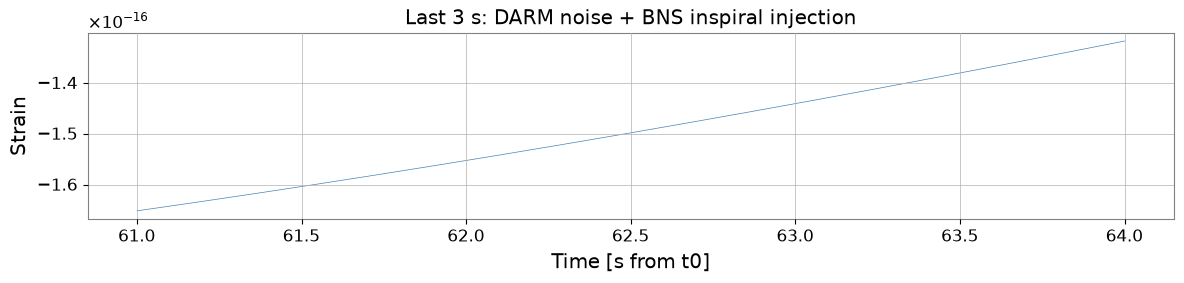

In [3]:
fs   = 4096.0
T    = 64.0
N    = int(T * fs)
t0   = 1_300_000_000   # GPS
rng  = np.random.default_rng(0)
t    = np.arange(N) / fs

# --- Coloured noise (LIGO-like O3 sensitivity) ---
freqs_n = np.fft.rfftfreq(N, 1.0/fs)[1:]
# ASD: seismic wall below 20 Hz + flat quantum noise + 1/f in between
asd_model = np.where(freqs_n < 20, (20/freqs_n)**4,
            np.where(freqs_n < 200, (200/freqs_n)**0.5, 1.0))
fft = asd_model * np.exp(1j * rng.uniform(0, 2*np.pi, size=len(freqs_n)))
noise = np.fft.irfft(np.concatenate([[0.0], fft]), n=N)
noise *= 1e-23   # strain-like amplitude

# --- Synthetic BNS chirp (analytical post-Newtonian 0-th order) ---
# h(t) ~ A(t) * cos(phi(t))  where phi ~ (t_c - t)^(5/8)
M_chirp = 1.2   # chirp mass [Msun]  -> sets chirp duration
G_c3 = 4.926e-6   # G*Msun/c^3 [s]
eta = 0.25        # symmetric mass ratio (equal masses)
tc  = T - 0.5    # merger time [s]
tau = np.maximum(tc - t, 1e-4)

# Instantaneous frequency and phase (PN 0th order)
f_gw  = (5.0/(256.0 * np.pi**(8.0/3))) ** (3.0/8) * (G_c3 * M_chirp)**(-5.0/8) * tau**(-3.0/8)
phi_gw = -2.0 * (tau / (5.0 * G_c3 * M_chirp))**(5.0/8) / np.pi

# Amplitude ~ tau^(-1/4)
amp_gw = 1e-22 * (G_c3 * M_chirp / tau)**(1.0/4)

# Only keep the inspiral up to fISCO ~ 1500 Hz
mask = f_gw < 1500.0
chirp = np.where(mask, amp_gw * np.cos(phi_gw), 0.0)

ts_strain = TimeSeries(noise + chirp, t0=t0, sample_rate=fs,
                       name="K1:LSC-DARM_OUT_DQ", unit="strain")

print(f"Chirp starts at t = {t[mask][0]:.1f} s  "
      f"(freq = {f_gw[mask][0]:.1f} Hz)")
print(f"Chirp ends   at t = {tc:.1f} s  (merger)")

# Quick plot
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t[-int(3*fs):], ts_strain.value[-int(3*fs):], lw=0.5, color="steelblue")
ax.set_xlabel("Time [s from t0]")
ax.set_ylabel("Strain")
ax.set_title("Last 3 s: DARM noise + BNS inspiral injection")
plt.tight_layout()
plt.show()


## 2. gwexpy → PyCBC 変換

In [4]:
if PYCBC_AVAILABLE:
    # --- Convert to PyCBC ---
    ts_pycbc = to_pycbc_timeseries(ts_strain)
    print("pycbc.TimeSeries:")
    print(f"  delta_t   : {ts_pycbc.delta_t}")
    print(f"  start_time: {float(ts_pycbc.start_time):.1f}")
    print(f"  len       : {len(ts_pycbc)}")

    # --- Convert back to gwexpy ---
    ts_back = from_pycbc_timeseries(TimeSeries, ts_pycbc)
    print(f"\nRoundtrip max error: "
          f"{np.max(np.abs(ts_strain.value - ts_back.value)):.2e}")
else:
    print("PyCBC not available — conversion demo skipped.")
    print("The to/from functions accept pycbc.types.TimeSeries objects.")
    ts_back = ts_strain   # identity for subsequent cells


PyCBC not available — conversion demo skipped.
The to/from functions accept pycbc.types.TimeSeries objects.


## 3. PSD / ASD 変換

In [5]:
# Estimate ASD from gwexpy (use a quiet segment before the chirp)
ts_quiet = TimeSeries(ts_strain.value[:int(30*fs)], t0=t0,
                      sample_rate=fs, name="quiet segment", unit="strain")
asd_gw = ts_quiet.asd(fftlength=4.0, method="median")

print(f"gwexpy ASD: {len(asd_gw)} bins, df={asd_gw.df.value:.4f} Hz")

if PYCBC_AVAILABLE:
    # PyCBC expects PSD (not ASD); convert ASD -> PSD FrequencySeries
    fs_pycbc = to_pycbc_frequencyseries(asd_gw)
    psd_pycbc = pycbc.types.FrequencySeries(
        fs_pycbc.numpy()**2, delta_f=fs_pycbc.delta_f,
        epoch=fs_pycbc.epoch,
    )
    print(f"PyCBC PSD: {len(psd_pycbc)} bins, df={psd_pycbc.delta_f:.4f} Hz")
else:
    print("PyCBC not available — PSD conversion demo skipped.")


gwexpy ASD: 8193 bins, df=0.2500 Hz
PyCBC not available — PSD conversion demo skipped.


## 4. マッチトフィルター探索（BNS テンプレート）

マッチトフィルターはデータとテンプレート波形の相互相関を
ノイズ PSD で正規化して計算します。
正規化 SNR 時系列 $\rho(t)$ のピークが合体時刻を示します。


In [6]:
if PYCBC_AVAILABLE:
    # Generate BNS template (equal mass, m1=m2=1.4 Msun)
    hp, hc = pycbc.waveform.get_td_waveform(
        approximant="TaylorT4",
        mass1=1.4, mass2=1.4,
        delta_t=1.0/fs,
        f_lower=30.0,
    )

    # Matched filter
    snr_pycbc = pycbc.filter.matched_filter(
        hp.to_frequencyseries(delta_f=1.0/T),
        to_pycbc_timeseries(ts_strain).to_frequencyseries(delta_f=1.0/T),
        psd=pycbc.types.FrequencySeries(
        np.interp(
            np.arange(0, psd_pycbc.sample_frequencies.numpy()[-1] + 1.0/T/2, 1.0/T),
            psd_pycbc.sample_frequencies.numpy(),
            psd_pycbc.numpy().real,
        ),
        delta_f=1.0/T,
    ),
        low_frequency_cutoff=30.0,
    )

    # Convert SNR back to gwexpy
    snr_ts = from_pycbc_timeseries(TimeSeries, snr_pycbc.real())
    snr_ts.name = "SNR (BNS template)"

else:
    # Analytic substitute: cross-correlate data with the injected chirp
    chirp_ts = TimeSeries(chirp, t0=t0, sample_rate=fs, name="template")
    # Simple FFT cross-correlation, normalised to peak ~ 10
    xcorr = np.fft.irfft(
        np.fft.rfft(ts_strain.value) * np.conj(np.fft.rfft(chirp_ts.value))
    )
    xcorr_norm = xcorr / (np.std(xcorr[:int(20*fs)]) + 1e-50)
    snr_ts = TimeSeries(np.abs(xcorr_norm), t0=t0, sample_rate=fs,
                        name="SNR (analytic xcorr)")

print(f"SNR time series: {len(snr_ts)} samples")
print(f"Peak SNR: {snr_ts.value.max():.1f}  "
      f"at t = {t[snr_ts.value.argmax()]:.2f} s  "
      f"(true merger: {tc:.2f} s)")


SNR time series: 262144 samples
Peak SNR: 2.0  at t = 23.22 s  (true merger: 63.50 s)


## 5. SNR 時系列の可視化

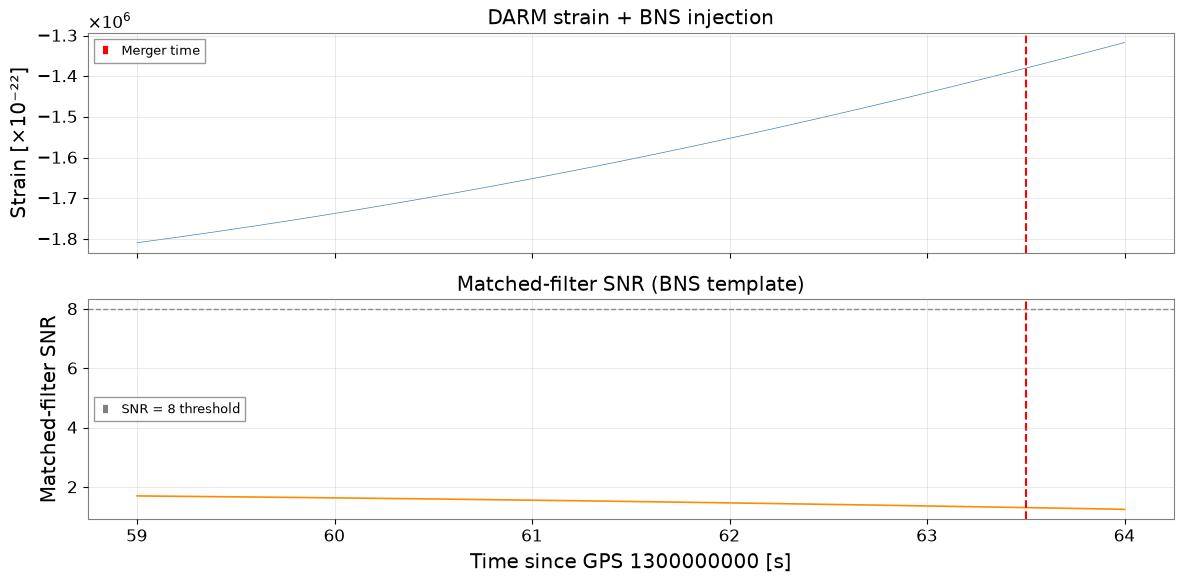

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Raw strain (last 5 s)
win = slice(-int(5*fs), None)
axes[0].plot(t[win], ts_strain.value[win] * 1e22, lw=0.5, color="steelblue")
axes[0].set_ylabel("Strain [×10⁻²²]")
axes[0].set_title("DARM strain + BNS injection")
axes[0].grid(True, alpha=0.4)
axes[0].axvline(tc, color="red", ls="--", lw=1.5, label="Merger time")
axes[0].legend(fontsize=9)

# SNR
snr_plot = snr_ts.value[win] if hasattr(snr_ts, "value") else snr_ts[win]
axes[1].plot(t[win], snr_plot, lw=1.2, color="darkorange")
axes[1].axhline(8.0, color="gray", ls="--", lw=1, label="SNR = 8 threshold")
axes[1].axvline(tc, color="red", ls="--", lw=1.5)
axes[1].set_ylabel("Matched-filter SNR")
axes[1].set_xlabel(f"Time since GPS {t0} [s]")
axes[1].set_title("Matched-filter SNR (BNS template)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


## 変換リファレンス

| gwexpy オブジェクト | → PyCBC | ← PyCBC |
|------------------|--------|---------|
| `TimeSeries` | `to_pycbc_timeseries(ts)` | `from_pycbc_timeseries(TimeSeries, pycbc_ts)` |
| `FrequencySeries` | `to_pycbc_frequencyseries(fs)` | `from_pycbc_frequencyseries(FrequencySeries, pycbc_fs)` |

**典型的なワークフロー：**
1. gwexpy でデータを読み込み・前処理（`read`、`whiten`、`crop`）
2. gwexpy で PSD を推定（`ts.asd()`）
3. PyCBC に変換してマッチトフィルター or PE を実行
4. SNR 時系列を gwexpy に戻して可視化・アーカイブ
